In [1]:
import cogsworth
import gala.potential as gp
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# this all just makes plots look nice
%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
p = cogsworth.pop.Population(n_binaries=100, processes=4,
                             final_kstar1=list(range(16)), final_kstar2=list(range(16)),
                             sfh_model=cogsworth.sfh.Wagg2022(),
                             galactic_potential=gp.MilkyWayPotential(version='v2'),
                             v_dispersion=5 * u.km / u.s,
                             max_ev_time=12.0 * u.Gyr, timestep_size=1 * u.Myr,
                             BSE_settings={}, sampling_params={}, store_entire_orbits=True,
                             use_default_BSE_settings=True)

In [4]:
p = cogsworth.pop.Population(n_binaries=1000, processes=4, max_ev_time=12.0 * u.Gyr,
                             use_default_BSE_settings=True)

In [5]:
# now let's get the initital stellar population
p.sample_initial_binaries()
p._initial_binaries

,kstar_1,kstar_2,mass_1,mass_2,porb,ecc,metallicity,tphysf,mass0_1,mass0_2,...,tacc_1,tacc_2,epoch_1,epoch_2,tms_1,tms_2,bhspin_1,bhspin_2,tphys,binfrac
0,0.0,0.0,0.315141,0.237802,4.707982,0.848973,0.027476,3757.812769,0.315141,0.237802,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.231263,0.151861,74444.055334,0.616752,0.030000,3414.805657,0.231263,0.151861,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.748870,0.569088,1137.259444,0.006560,0.007444,7956.431410,0.748870,0.569088,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.255084,0.085582,5.973114,0.025460,0.001126,2194.571045,0.255084,0.085582,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.273239,0.250952,1893.639998,0.037405,0.016313,976.319501,0.273239,0.250952,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299,1.0,0.0,0.709939,0.376113,53.269380,0.314557,0.011130,9214.340705,0.709939,0.376113,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1300,1.0,0.0,1.169294,0.128767,89.504234,0.019073,0.019907,6821.312805,1.169294,0.128767,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1301,0.0,0.0,0.128548,0.117100,3.499193,0.214564,0.006029,7401.934328,0.128548,0.117100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1302,0.0,0.0,0.391459,0.386078,196.105254,0.039243,0.009519,9160.456454,0.391459,0.386078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


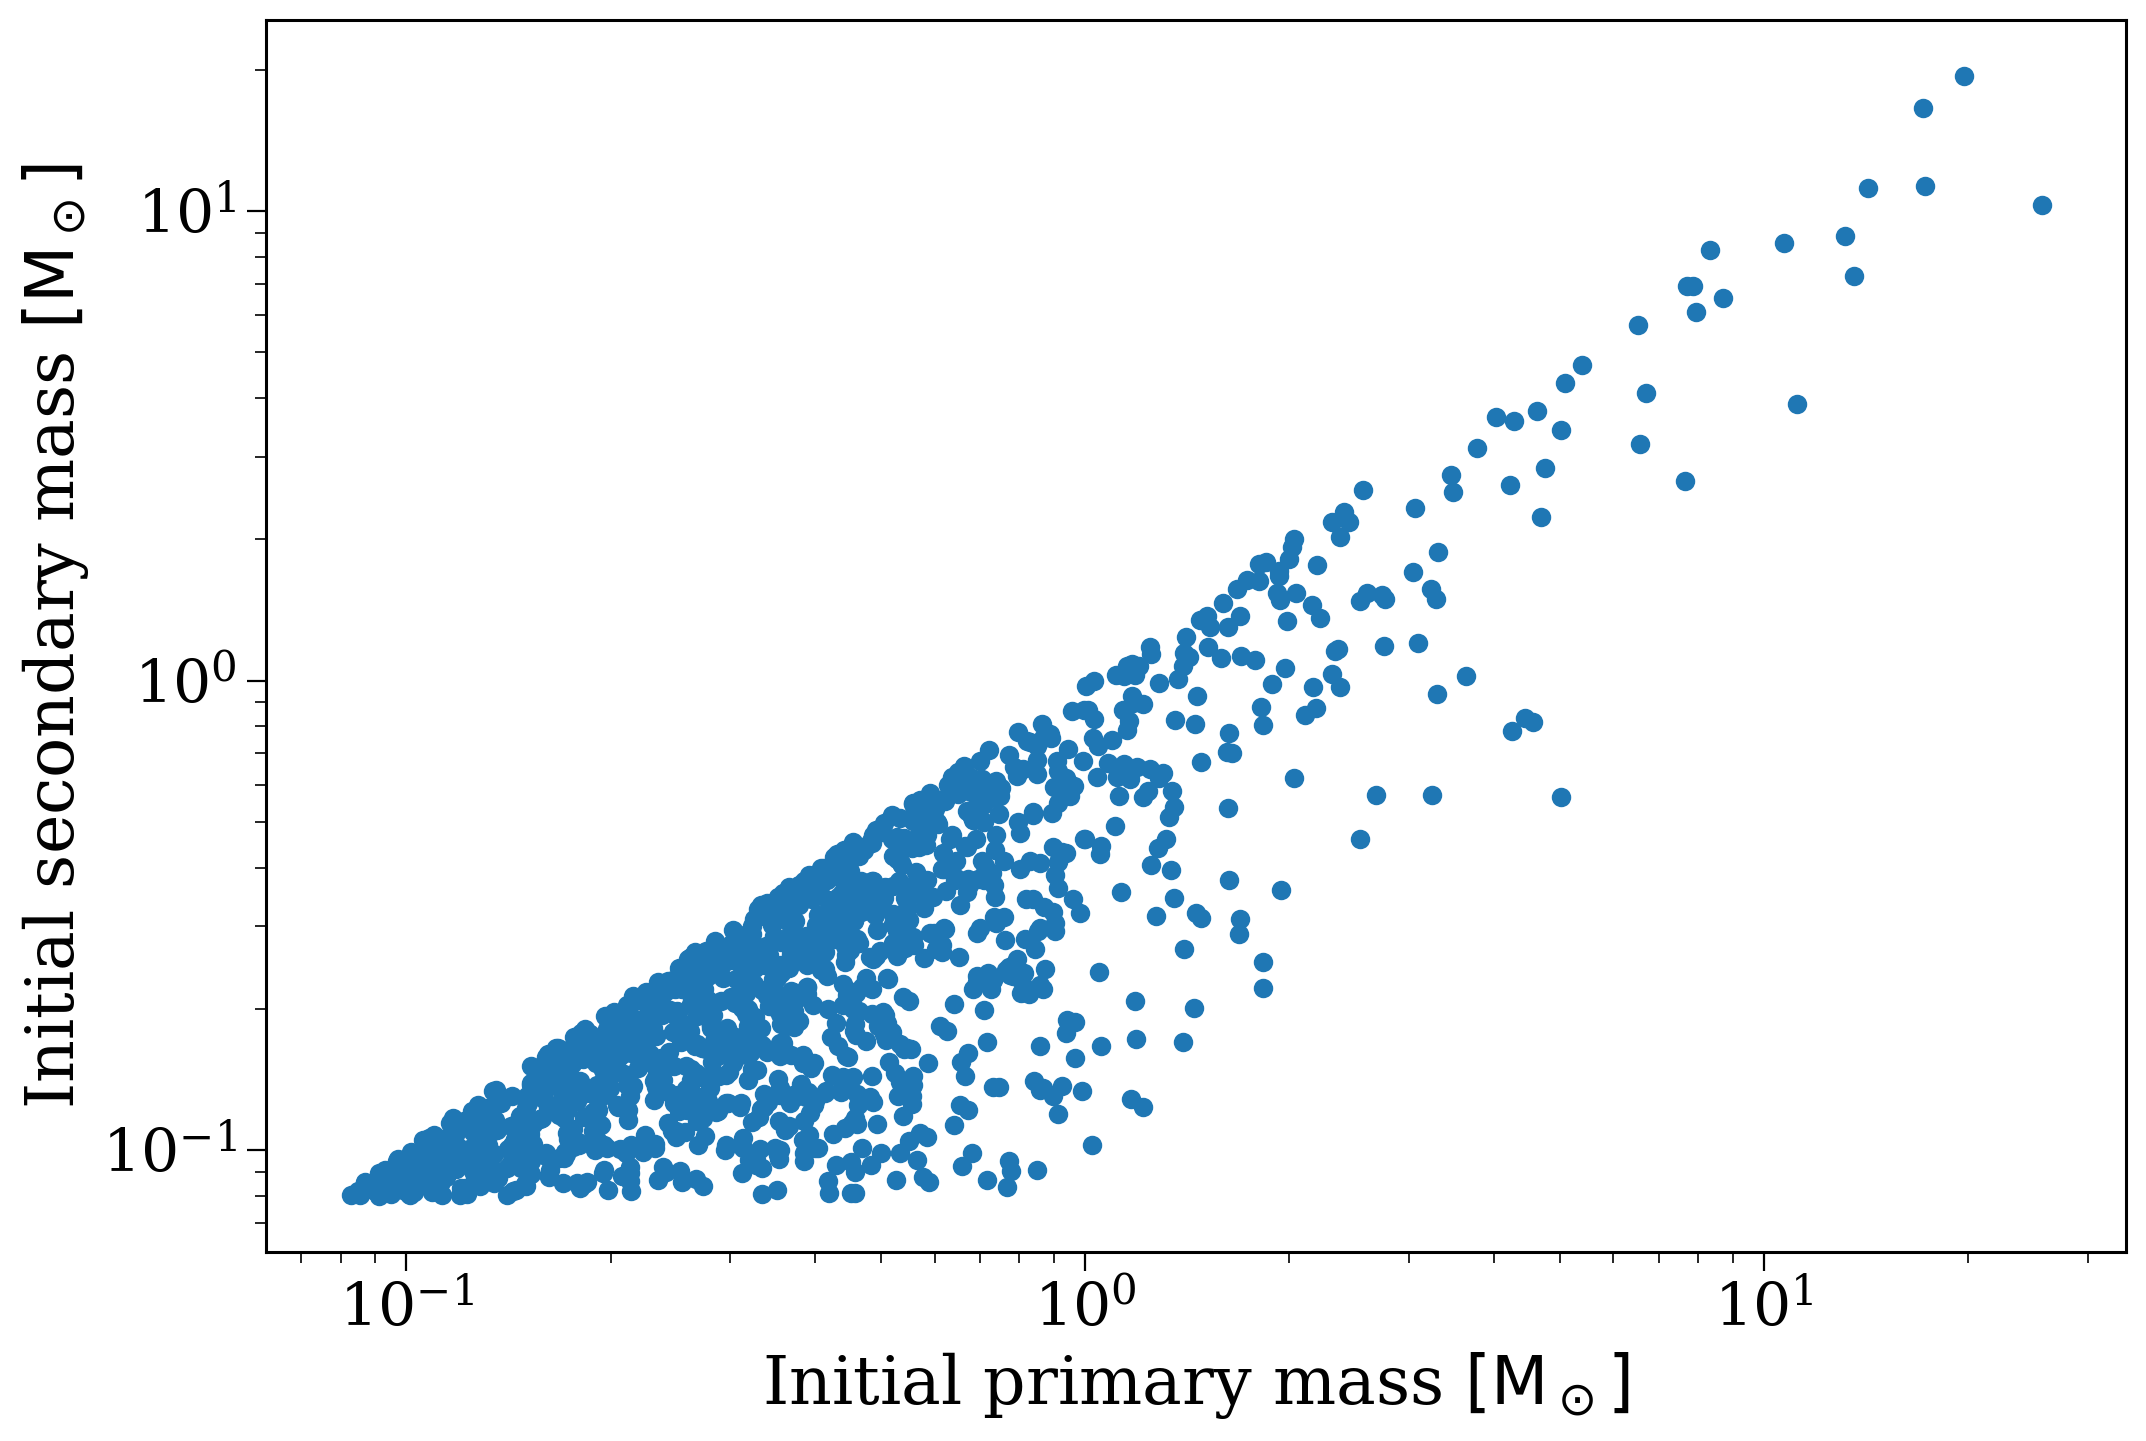

In [6]:
fig, ax = plt.subplots()
ax.scatter(p._initial_binaries["mass_1"], p._initial_binaries["mass_2"])
ax.set(xscale="log", yscale="log",
       xlabel=r"Initial primary mass $[\rm M_\odot]$", ylabel=r"Initial secondary mass $[\rm M_\odot]$")
plt.show()

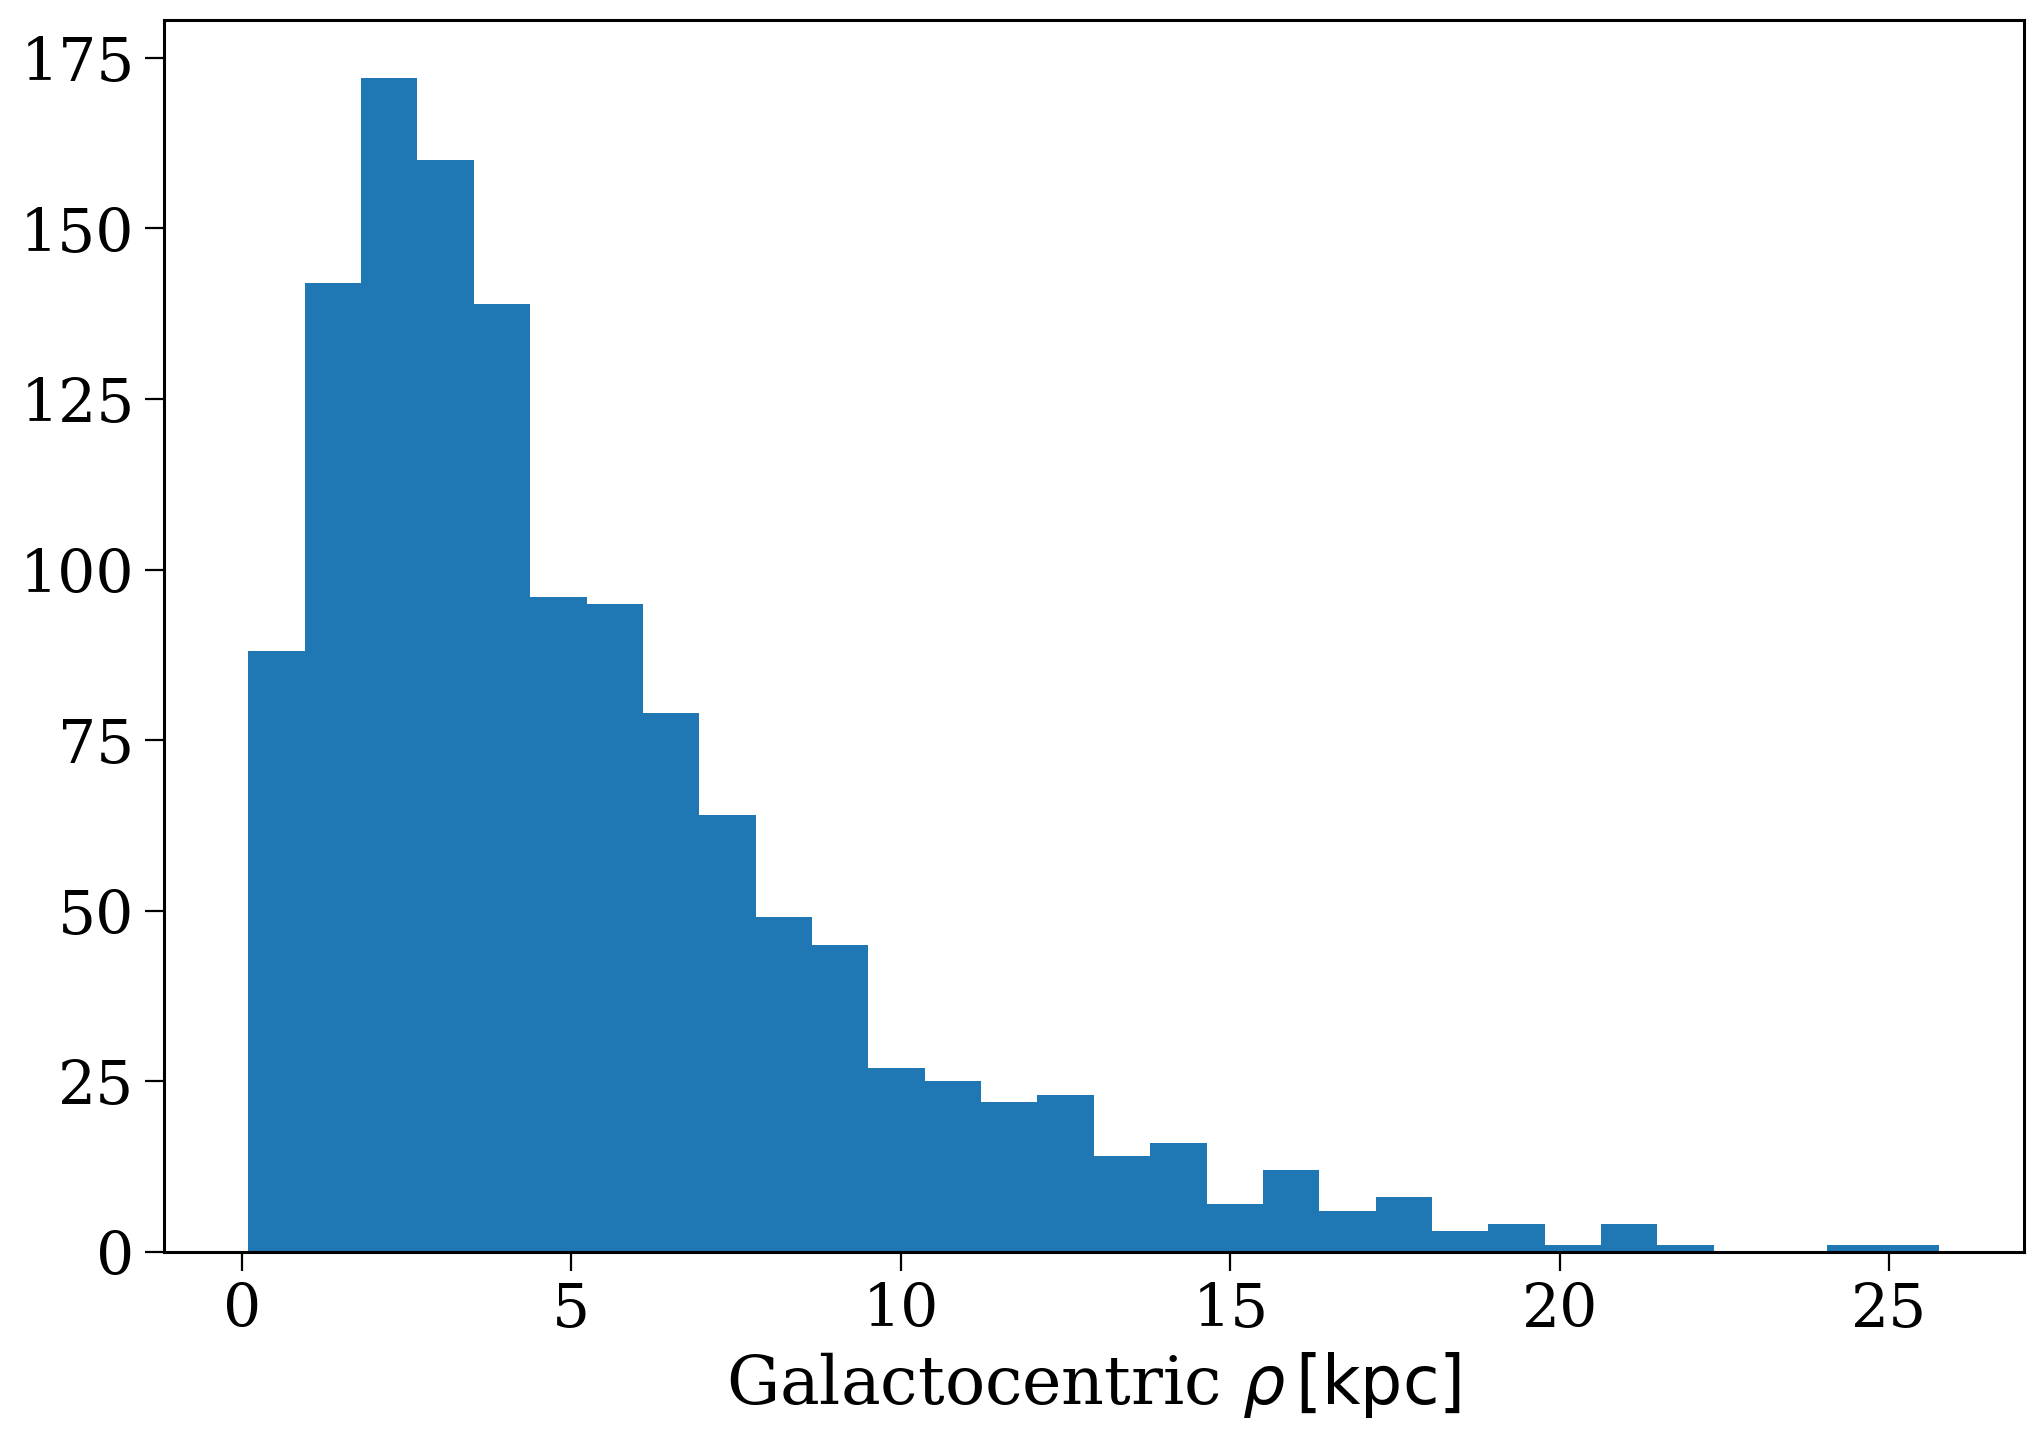

In [7]:
# first let's sample the initial galaxy
p.sample_initial_galaxy()

# and check distributions look normal
plt.hist(p.initial_galaxy.rho.value, bins="fd");
plt.xlabel(r"Galactocentric $\rho \, [\rm kpc]$");

In [8]:
p.perform_stellar_evolution()
p.bpp

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,...,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
0,0.000000,0.315141,0.237802,0,0,9.699181,4.707982,0.848973,0.541792,0.512880,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
0,3757.812769,0.315141,0.237802,0,0,6.642473,2.668253,0.779200,0.541947,0.512688,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.000000,0.231263,0.151861,0,0,5406.942159,74444.055334,0.616752,0.000306,0.000276,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,3414.805657,0.231263,0.151861,0,0,5406.942159,74444.055334,0.616752,0.000306,0.000276,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.000000,0.748870,0.569088,1,0,502.526231,1137.259444,0.006560,0.003441,0.002959,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1301,7401.934328,0.128548,0.117100,0,0,6.072176,3.498911,0.214546,0.085784,0.081986,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1301
1302,0.000000,0.391459,0.386078,0,0,130.572504,196.105254,0.039243,0.007664,0.007626,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1302
1302,9160.456454,0.391459,0.386078,0,0,130.572503,196.105253,0.039243,0.007731,0.007691,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1302
1303,0.000000,0.091023,0.089575,0,0,64.066782,139.850990,0.028575,0.006061,0.006138,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1303


In [9]:
# print out some evolution information for the most massive binary
# we'll cover more on how this masking works in the next few tutorials
p.bpp.loc[p.initial_binaries[p.initial_binaries["mass_1"] == p.initial_binaries["mass_1"].max()]["bin_num"].iloc[0]]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,...,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
1041,0.000000,25.642687,10.300848,1,1,24.597121,2.358241,0.019168,5.609188e-01,0.489863,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1041
1041,5.512373,25.043363,10.326454,1,1,23.603469,2.234701,0.000000,1.000249e+00,0.558423,...,0.0,0.0,0.0,0.0,0.0,-0.076161,0.014830,0.0,0.0,1041
1041,5.512373,0.000000,35.369817,15,1,0.000000,0.000000,-1.000000,0.000000e+00,-1.000000,...,0.0,0.0,0.0,0.0,0.0,-0.076161,5.148750,0.0,0.0,1041
1041,10.773904,0.000000,32.986648,15,2,0.000000,0.000000,-1.000000,-9.264869e-12,0.000100,...,0.0,0.0,0.0,0.0,0.0,-0.076161,4.963135,0.0,0.0,1041
1041,10.781241,0.000000,32.934501,15,4,0.000000,0.000000,-1.000000,-9.264869e-12,0.000100,...,0.0,0.0,0.0,0.0,0.0,-0.076161,4.963135,0.0,0.0,1041
1041,11.380735,0.000000,15.292669,15,5,0.000000,0.000000,-1.000000,-9.264869e-12,0.000100,...,0.0,0.0,0.0,0.0,0.0,-0.076161,4.963135,0.0,0.0,1041
1041,11.392238,0.000000,13.696400,15,5,0.000000,0.000000,-1.000000,-9.264869e-12,0.000100,...,0.0,0.0,0.0,0.0,0.0,-0.076161,4.963135,0.0,0.0,1041
1041,11.392238,0.000000,12.438530,15,14,0.000000,0.000000,-1.000000,-9.264869e-12,0.000100,...,0.0,0.0,0.0,0.0,0.0,-0.076161,11.392238,0.0,0.0,1041
1041,11080.186301,0.000000,12.438530,15,14,0.000000,0.000000,-1.000000,-9.264869e-12,0.000100,...,0.0,0.0,0.0,0.0,0.0,-0.076161,11.392238,0.0,0.0,1041


In [10]:
p.perform_galactic_evolution()
p.orbits

Integrating orbits: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1311/1311 [00:01<00:00, 669.52it/s]


array([<Orbit cartesian, dim=3, shape=(7607,)>,
       <Orbit cartesian, dim=3, shape=(1973,)>,
       <Orbit cartesian, dim=3, shape=(1838,)>, ...,
       <Orbit cartesian, dim=3, shape=(11751,)>,
       <Orbit cartesian, dim=3, shape=(10639,)>,
       <Orbit cartesian, dim=3, shape=(8909,)>],
      shape=(1311,), dtype=object)

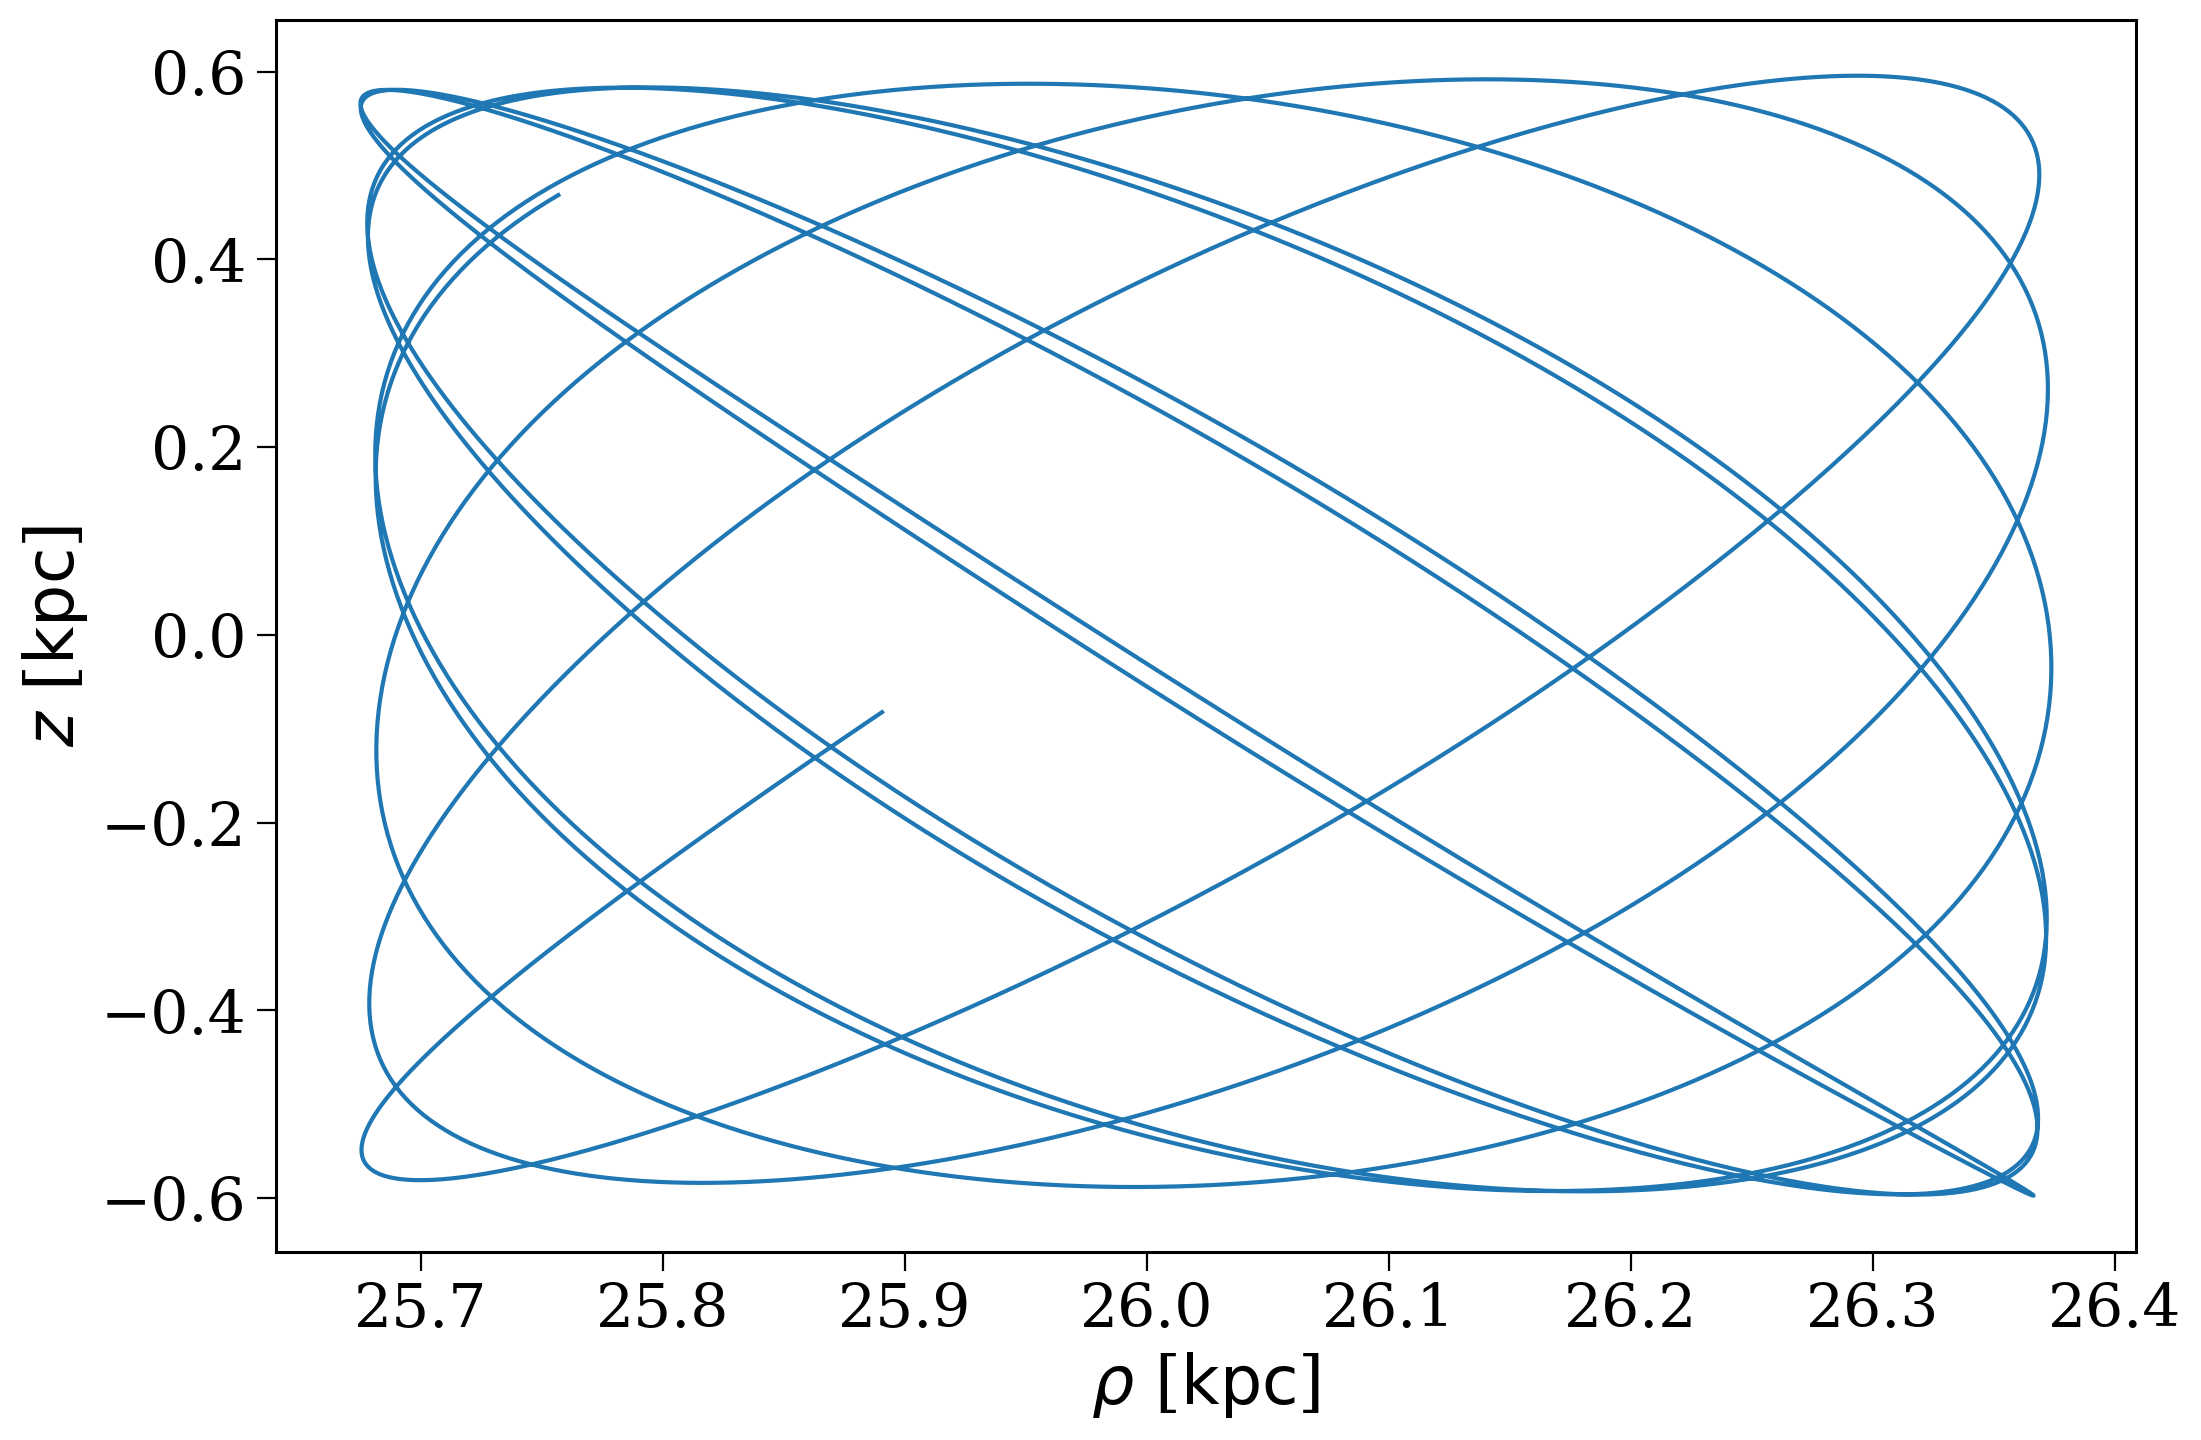

In [11]:
fig, ax = plt.subplots()
p.orbits[np.random.randint(0, len(p.orbits))].cylindrical.plot(["rho", "z"], axes=[ax]);

In [12]:
p.create_population()

Run for 1000 binaries
Sampled 1310 binaries
[4e-02s] Sample initial binaries
[0.3s] Evolve binaries (run COSMIC)


Integrating orbits: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1311/1311 [00:01<00:00, 702.57it/s]


[3.0s] Integrate galactic orbits (run gala)
Overall: 3.3s


Check out the next tutorial to learn more about interpretting the outputs of these simulations.